AGREGACIÓN HORARIA 

In [1]:
import pandas as pd
import numpy as np

# =========================
# 1) CARGA
# =========================
df_orig = pd.read_csv("data_clean_interpolated.csv")
df_meteo = pd.read_csv("meteo_clean_interpolated.csv")

df_orig["instante"] = pd.to_datetime(df_orig["instante"], errors="coerce")
df_meteo["instante"] = pd.to_datetime(df_meteo["instante"], errors="coerce")

df_orig = df_orig.dropna(subset=["instante"]).sort_values("instante")
df_meteo = (
    df_meteo.dropna(subset=["instante"])
    .sort_values("instante")
    .drop_duplicates(subset=["instante"], keep="last")
)

# =========================
# 2) AJUSTES DE COLUMNAS
# =========================
# En orig quitas HA/TA porque vienen en meteo
df_orig = df_orig.drop(columns=["HA", "TA"], errors="ignore")

# En meteo quitas eto y precipitacion
# Ajusta estos nombres si en tu csv están separados en dos columnas distintas
df_meteo_sel = df_meteo.drop(columns=["eto", "precipitacion", "eto, precipitacion"], errors="ignore")

# =========================
# 3) MERGE
# =========================
df = df_orig.merge(df_meteo_sel, on="instante", how="left")

# =========================
# 4) AGREGACIÓN HORARIA
# =========================
df = df.set_index("instante").sort_index()

num_cols = df.select_dtypes(include="number").columns.tolist()

# Por defecto: media para todas las columnas numéricas
agg_dict = {c: ["mean"] for c in num_cols}

# ---- Añadir mínimo para HS30 ----
# Además de la media, queremos también el mínimo horario de HS30
if "HS30" in agg_dict:
    agg_dict["HS30"] = ["mean", "min"]

# ---- Correcciones riego ----
# 1) litros_arbol es ACUMULADO (escalera) -> mejor last
if "litros_arbol" in agg_dict:
    agg_dict["litros_arbol"] = ["last"]

# 2) litros_intervalo es LITROS POR 10 MIN -> por hora lo correcto es suma
if "litros_intervalo" in agg_dict:
    agg_dict["litros_intervalo"] = ["sum"]

# 3) evento_riego es binaria -> max indica si hubo riego en esa hora
if "evento_riego" in agg_dict:
    agg_dict["evento_riego"] = ["max"]

df_hourly = df.resample("H").agg(agg_dict)

# Aplanar MultiIndex: var_stat
df_hourly.columns = [f"{var}_{stat}" for var, stat in df_hourly.columns]
df_hourly = df_hourly.reset_index()

# =========================
# 5) GUARDAR
# =========================
df.reset_index().to_csv("data_10min_plus_meteo.csv", index=False)
df_hourly.to_csv("data_hourly_agg.csv", index=False)

print("Guardado:")
print("- data_10min_plus_meteo.csv (10 min, cruzado con meteo)")
print("- data_hourly_agg.csv (horario, agg corregida para riego y con HS30_min)")
print("Dimensiones hourly:", df_hourly.shape)

# =========================
# 6) CHEQUEO RÁPIDO
# =========================
if "HS30_min" in df_hourly.columns:
    print("\nResumen de HS30_min:")
    print(df_hourly["HS30_min"].describe())

if "litros_intervalo_sum" in df_hourly.columns:
    print("\nLitros por hora (suma):")
    print(df_hourly["litros_intervalo_sum"].describe())

if "evento_riego_max" in df_hourly.columns:
    print("\nHoras con riego (conteo):", int(df_hourly["evento_riego_max"].sum()))

C:\Users\Iratxe\AppData\Local\Temp\ipykernel_10624\2011219463.py:63: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample("H").agg(agg_dict)


Guardado:
- data_10min_plus_meteo.csv (10 min, cruzado con meteo)
- data_hourly_agg.csv (horario, agg corregida para riego y con HS30_min)
Dimensiones hourly: (45457, 16)

Resumen de HS30_min:
count    17452.000000
mean         0.768422
std          0.038686
min          0.672300
25%          0.741642
50%          0.769808
75%          0.797578
max          0.866059
Name: HS30_min, dtype: float64

Litros por hora (suma):
count    45457.000000
mean         0.518904
std          2.434188
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         24.800000
Name: litros_intervalo_sum, dtype: float64

Horas con riego (conteo): 2616


In [42]:
import matplotlib.pyplot as plt

def plot_before_after_aggregation(var, year, df_orig, df_agg):
    """
    Función para graficar los datos antes y después de la agregación horaria de una variable y un año específico.
    
    :param var: Nombre de la variable a graficar (ej. "TA", "precipitacion", "radiacion").
    :param year: Año específico para graficar.
    :param df_orig: DataFrame original con datos sin agregar (con intervalo original, ej. 10min).
    :param df_agg: DataFrame con los datos agregados por hora.
    """
    
    # Restablecer el índice de ambos dataframes, asegurándonos de que "instante" sea una columna
    df_orig = df_orig.reset_index()  # Asegura que 'instante' sea una columna
    df_agg = df_agg.reset_index()    # Asegura que 'instante' sea una columna

    # Filtramos los datos por año
    df_before = df_orig[df_orig["instante"].dt.year == year].copy()
    df_after = df_agg[df_agg["instante"].dt.year == year].copy()

    # El nombre de la columna en df_agg será var_mean (por ejemplo, TA_mean, etc.)
    var_agg = f"{var}_mean"

    # Creamos los gráficos
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Primer gráfico: Datos originales (antes de la agregación)
    axes[0].scatter(df_before["instante"], df_before[var], s=10, color='orange', alpha=0.5)
    axes[0].set_title(f"{var} — Original ({year})")
    axes[0].set_ylabel(var)
    axes[0].grid(True, alpha=0.3)

    # Segundo gráfico: Datos agregados por hora (después de la agregación)
    axes[1].scatter(df_after["instante"], df_after[var_agg], s=10, color='blue', alpha=0.5)
    axes[1].set_title(f"{var} — Agregados por hora ({year})")
    axes[1].set_ylabel(var)
    axes[1].set_xlabel("Tiempo")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

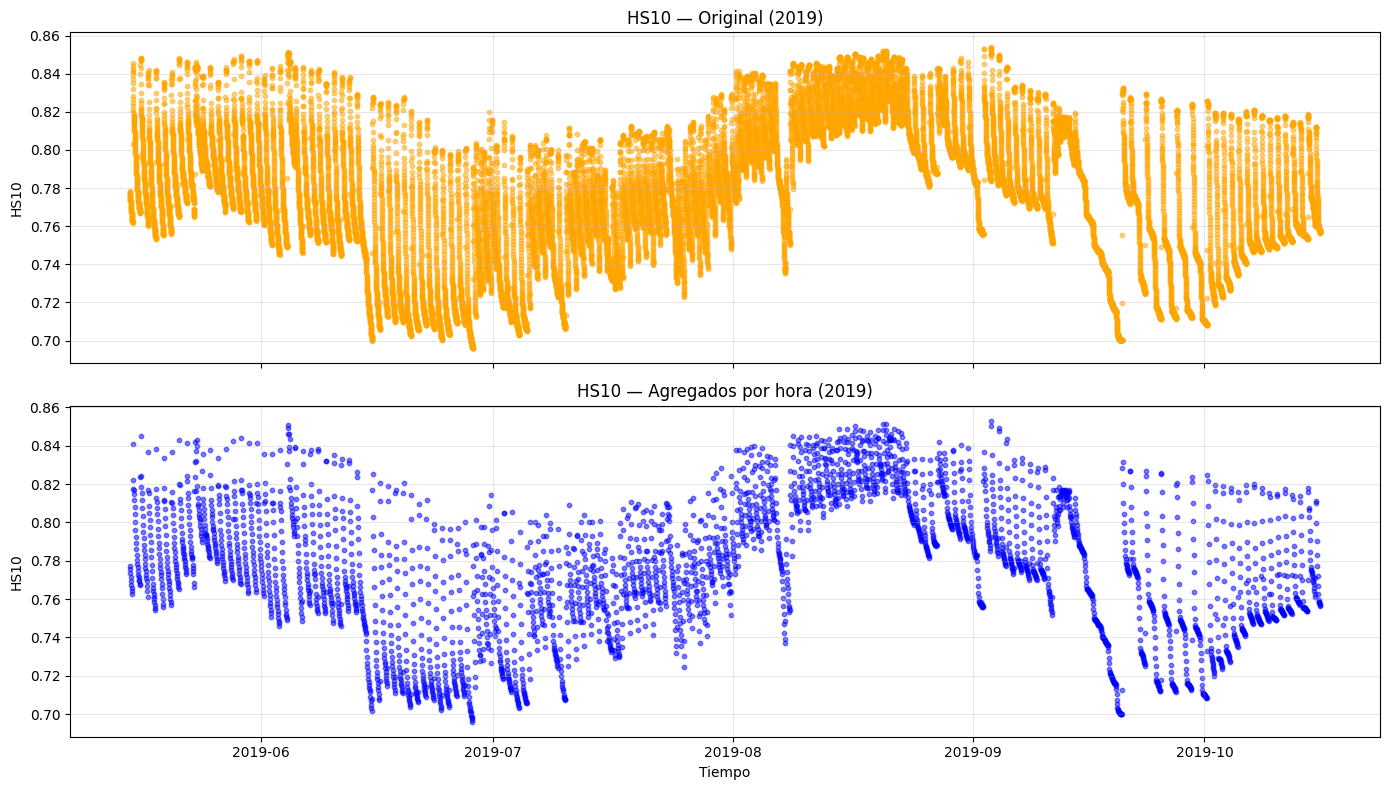

In [ ]:
plot_before_after_aggregation("HS10", 2019, df, df_hourly)